<a href="https://colab.research.google.com/github/naumankhokhar/sp500-ml-clustering-portfolio-optimization/blob/Pris/Stock_Analysis_GroupCW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
# =========================================
# CW2 - Data Warehousing & BI Coursework
# Group 12:  Nauman, Ahmad and Prismika
# =========================================

In [104]:
# 1. INSTALL AND IMPORT LIBRARIES

!pip install yfinance yahoofinancials scikit-learn scipy --quiet

import pandas as pd
import numpy as np
import yfinance as yf
from yahoofinancials import YahooFinancials
import requests
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [105]:
# 2. EXTRACT S&P 500 TICKERS USING PANDAS

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

sp500_table = pd.read_html(response.text)[0]

tickers = sp500_table["Symbol"].tolist()

# Yahoo Finance uses '-' instead of '.' in tickers
tickers = [ticker.replace(".", "-") for ticker in tickers]

print("Number of extracted tickers:", len(tickers))
print("First 20 tickers:")
print(tickers[:20])

/tmp/ipykernel_13667/14654775.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(response.text)[0]


Number of extracted tickers: 503
First 20 tickers:
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL']


In [106]:
# 3. LOAD DAILY STOCK PERFORMANCE USING YFINANCE
# Period: 01-01-2022 to 01-01-2025


start_date = "2022-01-01"
end_date = "2025-01-01"

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=False
)["Adj Close"]

print("Raw price data size / dimensionality:", price_data.shape)
price_data.head()

ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


Raw price data size / dimensionality: (753, 503)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103638,114.894035,172.679993,127.545822,42.362530,380.485321,564.369995,164.526474,60.037273,...,33.979378,85.125763,59.164799,54.760239,110.957481,164.029999,125.887230,120.797722,583.900024,223.051025
2022-01-04,146.573669,175.843262,114.673447,170.800003,124.546143,42.914051,377.766266,554.000000,163.040497,61.151539,...,34.414909,84.854218,59.539249,56.819992,112.134544,156.330002,126.560310,122.023201,587.599976,214.559052
2022-01-05,144.062759,171.165848,115.275826,162.250000,123.986595,42.410072,371.113586,514.429993,160.523590,60.673988,...,33.560608,81.711830,60.122715,57.526691,110.606247,143.490005,124.955925,121.620926,558.179993,206.400604
2022-01-06,144.566864,168.308487,114.732857,159.750000,123.968216,42.657307,353.192322,514.119995,161.034378,61.213432,...,33.828625,82.090080,59.652462,58.879757,110.454361,144.660004,126.246811,120.610619,555.159973,207.220276
2022-01-07,140.718094,168.474838,114.435898,166.050003,124.353500,42.856995,346.418030,510.700012,156.808655,61.735172,...,33.786743,82.002785,60.174961,59.362366,109.571579,141.539993,124.799232,119.880951,530.859985,201.187195


In [107]:
# 4. USE YAHOOFINANCIALS PACKAGE AS REQUIRED (SAFE VERSION)

try:
    sample_tickers = tickers[:3]  # keep small to avoid issues

    yf_fin = YahooFinancials(sample_tickers)

    sample_data = yf_fin.get_historical_price_data(
        start_date,
        end_date,
        "daily"
    )

    print("YahooFinancials sample loaded for:")
    print(list(sample_data.keys()))

except Exception as e:
    print("YahooFinancials could not retrieve data.")
    print("This package is included to demonstrate usage as required.")
    print("Error:", e)

YahooFinancials could not retrieve data.
This package is included to demonstrate usage as required.
Error: 'NoneType' object has no attribute 'name'


In [108]:
# 5. IDENTIFY INVALID DATA
# Invalid data = missing values / NaN values

print("Before cleaning:", price_data.shape)

missing_values = price_data.isna().sum()

missing_summary = pd.DataFrame({
    "Ticker": missing_values.index,
    "Missing Values": missing_values.values
}).sort_values(by="Missing Values", ascending=False)

missing_summary.head(20)

Before cleaning: (753, 503)


,Ticker,Missing Values
409,SNDK,753
384,Q,753
206,GEV,560
412,SOLV,559
468,VLTO,440
275,KVUE,335
204,GEHC,240
86,CEG,11
333,NOC,0
334,NOW,0


In [109]:
# 6. REMOVE INVALID DATA

clean_data = price_data.dropna(axis=1)

print("After cleaning:", clean_data.shape)

removed_tickers = list(set(price_data.columns) - set(clean_data.columns))

print("Number of removed tickers:", len(removed_tickers))
print("Removed tickers:")
print(removed_tickers[:20])

clean_data.head()

After cleaning: (753, 495)
Number of removed tickers: 8
Removed tickers:
['SOLV', 'CEG', 'Q', 'KVUE', 'VLTO', 'GEV', 'GEHC', 'SNDK']


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103638,114.894035,172.679993,127.545822,42.362530,380.485321,564.369995,164.526474,60.037273,...,33.979378,85.125763,59.164799,54.760239,110.957481,164.029999,125.887230,120.797722,583.900024,223.051025
2022-01-04,146.573669,175.843262,114.673447,170.800003,124.546143,42.914051,377.766266,554.000000,163.040497,61.151539,...,34.414909,84.854218,59.539249,56.819992,112.134544,156.330002,126.560310,122.023201,587.599976,214.559052
2022-01-05,144.062759,171.165848,115.275826,162.250000,123.986595,42.410072,371.113586,514.429993,160.523590,60.673988,...,33.560608,81.711830,60.122715,57.526691,110.606247,143.490005,124.955925,121.620926,558.179993,206.400604
2022-01-06,144.566864,168.308487,114.732857,159.750000,123.968216,42.657307,353.192322,514.119995,161.034378,61.213432,...,33.828625,82.090080,59.652462,58.879757,110.454361,144.660004,126.246811,120.610619,555.159973,207.220276
2022-01-07,140.718094,168.474838,114.435898,166.050003,124.353500,42.856995,346.418030,510.700012,156.808655,61.735172,...,33.786743,82.002785,60.174961,59.362366,109.571579,141.539993,124.799232,119.880951,530.859985,201.187195


In [110]:
# 7. CALCULATE DAILY RETURN
# Formula:
# Daily Return = (Price Today - Price Yesterday) / Price Yesterday


daily_returns = clean_data.pct_change().dropna()

print("Daily returns size / dimensionality:", daily_returns.shape)
daily_returns.head()

Daily returns size / dimensionality: (752, 495)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012691,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018560,...,0.012818,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024824,-0.037033,0.009800,0.012438,-0.013629,-0.082134,-0.012677,-0.003297,-0.050068,-0.038024
2022-01-06,0.003499,-0.016694,-0.004710,-0.015408,-0.000148,0.005830,-0.048291,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007822,0.023521,-0.001373,0.008154,0.010331,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000988,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026241,0.008523,...,-0.001238,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011466,-0.006050,-0.043771,-0.029114
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009239,0.001719,...,-0.004710,-0.028149,0.010998,-0.005952,-0.010136,0.020772,-0.013964,-0.009754,0.008571,0.007154


In [111]:
# 8. DOWNLOAD S&P 500 INDEX RETURNS FOR BETA CALCULATION

sp500_index = yf.download(
    "^GSPC",
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=False
)["Adj Close"]

# Make sure it is a Series, not a DataFrame
if isinstance(sp500_index, pd.DataFrame):
    sp500_index = sp500_index.iloc[:, 0]

sp500_returns = sp500_index.pct_change().dropna()

print("S&P 500 index returns shape:", sp500_returns.shape)
sp500_returns.head()

S&P 500 index returns shape: (752,)


,^GSPC
Date,
2022-01-04,-0.000630
2022-01-05,-0.019393
2022-01-06,-0.000964
2022-01-07,-0.004050
2022-01-10,-0.001441


In [112]:
# 9. CALCULATE BETA VALUES

beta_values = {}

for stock in daily_returns.columns:
    stock_ret = daily_returns[stock]

    # Align dates between stock returns and market returns
    aligned_data = pd.concat([stock_ret, sp500_returns], axis=1, join="inner").dropna()
    aligned_data.columns = ["Stock Return", "Market Return"]

    correlation = aligned_data["Stock Return"].corr(aligned_data["Market Return"])
    stock_std = aligned_data["Stock Return"].std()
    market_std = aligned_data["Market Return"].std()

    beta = correlation * (stock_std / market_std)
    beta_values[stock] = beta

beta_df = pd.DataFrame(beta_values.items(), columns=["Ticker", "Beta"])
beta_df = beta_df.sort_values(by="Beta", ascending=False)

print("Extracted beta values:")
beta_df.head(20)

Extracted beta values:


,Ticker,Beta
125,CVNA,3.294068
105,COIN,2.960959
490,XYZ,2.544784
336,NVDA,2.268515
39,APP,2.261933
443,TTD,2.237123
364,PLTR,2.189588
310,MPWR,2.134131
26,AMD,2.064749
464,VRT,2.060915


In [113]:
# 10. CALCULATE ANNUAL VOLATILITY
# Formula:
# Annual Volatility = Daily Return Standard Deviation * sqrt(252)


annual_volatility = daily_returns.std() * np.sqrt(252)

volatility_df = pd.DataFrame({
    "Ticker": annual_volatility.index,
    "Annual Volatility": annual_volatility.values
}).sort_values(by="Annual Volatility", ascending=False)

print("Extracted annual volatility values:")
volatility_df.head(20)

Extracted annual volatility values:


,Ticker,Annual Volatility
125,CVNA,1.341039
105,COIN,0.953848
402,SMCI,0.901957
39,APP,0.788374
364,PLTR,0.690932
490,XYZ,0.653825
226,HOOD,0.651759
443,TTD,0.647665
464,VRT,0.629826
440,TSLA,0.613038


In [114]:
# 11. CREATE FINAL METRICS TABLE

average_daily_return = daily_returns.mean()

metrics_df = pd.DataFrame({
    "Ticker": daily_returns.columns,
    "Daily Return": [average_daily_return[t] for t in daily_returns.columns],
    "Beta": [beta_values[t] for t in daily_returns.columns],
    "Annual Volatility": [annual_volatility[t] for t in daily_returns.columns]
})

metrics_df = metrics_df.dropna()

print("Final metrics table size / dimensionality:", metrics_df.shape)
metrics_df.head()

Final metrics table size / dimensionality: (495, 4)


,Ticker,Daily Return,Beta,Annual Volatility
0,A,-0.000002,1.024800,0.296259
1,AAPL,0.000591,1.210689,0.270935
2,ABBV,0.000610,0.299099,0.219958
3,ABNB,0.000074,1.666256,0.467875
4,ABT,-0.000106,0.672317,0.217839


In [115]:
# 12. STANDARDISE FEATURES BEFORE CLUSTERING

features = metrics_df[["Daily Return", "Beta", "Annual Volatility"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaled features shape:", scaled_features.shape)

Scaled features shape: (495, 3)


In [116]:
# 13. FIND BEST NUMBER OF CLUSTERS USING SILHOUETTE SCORE
# This can be used for both Agglomerative Clustering and K-Means

cluster_range = range(2, 8)

silhouette_results = []

for n in cluster_range:
    agg_model = AgglomerativeClustering(n_clusters=n, linkage="ward")
    agg_labels = agg_model.fit_predict(scaled_features)
    agg_score = silhouette_score(scaled_features, agg_labels)

    kmeans_model = KMeans(n_clusters=n, random_state=42, n_init=10)
    kmeans_labels = kmeans_model.fit_predict(scaled_features)
    kmeans_score = silhouette_score(scaled_features, kmeans_labels)

    silhouette_results.append([n, agg_score, kmeans_score])

silhouette_df = pd.DataFrame(
    silhouette_results,
    columns=["Number of Clusters", "Agglomerative Silhouette", "K-Means Silhouette"]
)

silhouette_df

,Number of Clusters,Agglomerative Silhouette,K-Means Silhouette
0,2,0.450747,0.463550
1,3,0.428112,0.310726
2,4,0.246001,0.300364
3,5,0.242759,0.298850
4,6,0.228769,0.296048
5,7,0.224776,0.286570


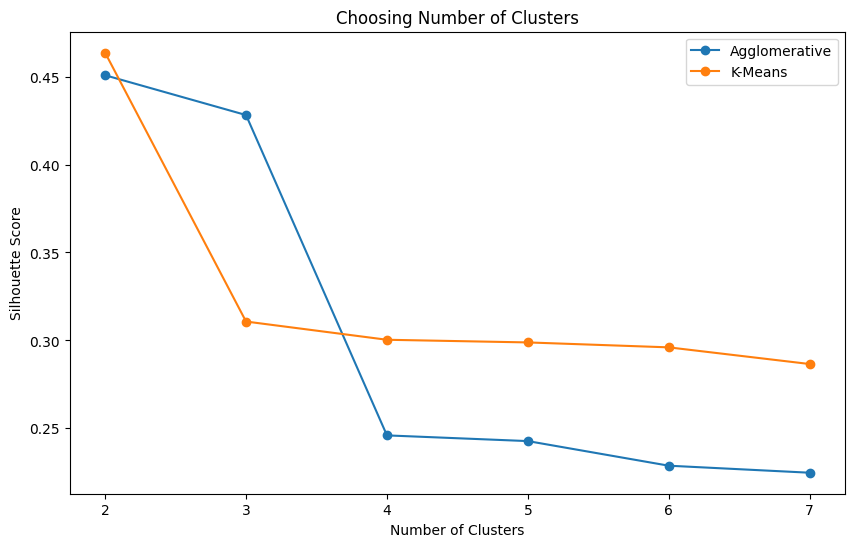

In [117]:
# 14. DIAGRAM: SILHOUETTE SCORES

plt.figure(figsize=(10,6))
plt.plot(
    silhouette_df["Number of Clusters"],
    silhouette_df["Agglomerative Silhouette"],
    marker="o",
    label="Agglomerative"
)
plt.plot(
    silhouette_df["Number of Clusters"],
    silhouette_df["K-Means Silhouette"],
    marker="o",
    label="K-Means"
)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Choosing Number of Clusters")
plt.legend()
plt.show()

In [118]:
# 15. AGGLOMERATIVE CLUSTERING
# We use 3 clusters for simple Low / Medium / High risk categories

agg_clustering = AgglomerativeClustering(n_clusters=3, linkage="ward")

metrics_df["Agglomerative Cluster"] = agg_clustering.fit_predict(scaled_features)

metrics_df.head()

,Ticker,Daily Return,Beta,Annual Volatility,Agglomerative Cluster
0,A,-0.000002,1.024800,0.296259,0
1,AAPL,0.000591,1.210689,0.270935,0
2,ABBV,0.000610,0.299099,0.219958,0
3,ABNB,0.000074,1.666256,0.467875,1
4,ABT,-0.000106,0.672317,0.217839,0


In [119]:
# 16. AGGLOMERATIVE CLUSTER SUMMARY

agg_summary = metrics_df.groupby("Agglomerative Cluster")[
    ["Daily Return", "Beta", "Annual Volatility"]
].mean().round(4)

agg_counts = metrics_df["Agglomerative Cluster"].value_counts().sort_index()

print("Agglomerative cluster sizes:")
print(agg_counts)

print("\nAgglomerative cluster summary:")
print(agg_summary)

Agglomerative cluster sizes:
Agglomerative Cluster
0    386
1    102
2      7
Name: count, dtype: int64

Agglomerative cluster summary:
                       Daily Return    Beta  Annual Volatility
Agglomerative Cluster                                         
0                            0.0003  0.7762             0.2708
1                            0.0006  1.4759             0.4418
2                            0.0029  2.4130             0.8370


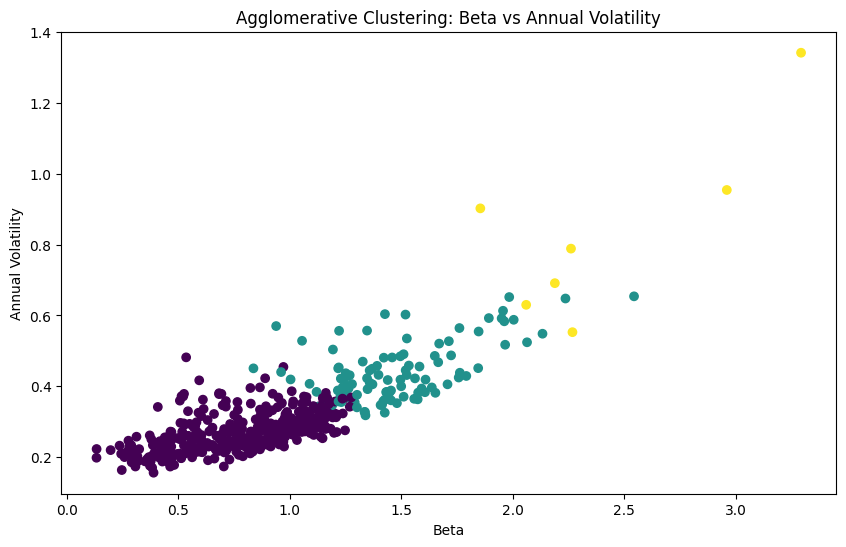

In [120]:
# 17. DIAGRAM: AGGLOMERATIVE CLUSTERING

plt.figure(figsize=(10,6))
plt.scatter(
    metrics_df["Beta"],
    metrics_df["Annual Volatility"],
    c=metrics_df["Agglomerative Cluster"]
)
plt.xlabel("Beta")
plt.ylabel("Annual Volatility")
plt.title("Agglomerative Clustering: Beta vs Annual Volatility")
plt.show()

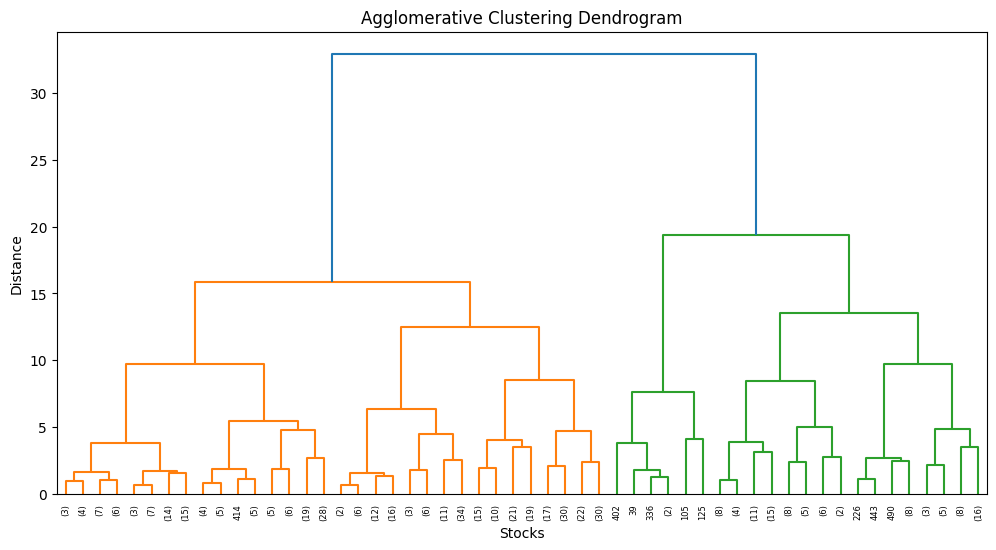

In [121]:
# 18. OPTIONAL DENDROGRAM FOR AGGLOMERATIVE CLUSTERING

linked = linkage(scaled_features, method="ward")

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Stocks")
plt.ylabel("Distance")
plt.show()

In [122]:
# 19. K-MEANS CLUSTERING

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

metrics_df["KMeans Cluster"] = kmeans.fit_predict(scaled_features)

metrics_df.head()

,Ticker,Daily Return,Beta,Annual Volatility,Agglomerative Cluster,KMeans Cluster
0,A,-0.000002,1.024800,0.296259,0,2
1,AAPL,0.000591,1.210689,0.270935,0,2
2,ABBV,0.000610,0.299099,0.219958,0,0
3,ABNB,0.000074,1.666256,0.467875,1,2
4,ABT,-0.000106,0.672317,0.217839,0,0


In [123]:
# 20. K-MEANS CLUSTER SUMMARY

kmeans_summary = metrics_df.groupby("KMeans Cluster")[
    ["Daily Return", "Beta", "Annual Volatility"]
].mean().round(4)

kmeans_counts = metrics_df["KMeans Cluster"].value_counts().sort_index()

print("K-Means cluster sizes:")
print(kmeans_counts)

print("\nK-Means cluster summary:")
print(kmeans_summary)

K-Means cluster sizes:
KMeans Cluster
0    290
1     48
2    157
Name: count, dtype: int64

K-Means cluster summary:
                Daily Return    Beta  Annual Volatility
KMeans Cluster                                         
0                     0.0005  0.6924             0.2528
1                     0.0015  1.7202             0.5345
2                     0.0000  1.1700             0.3599


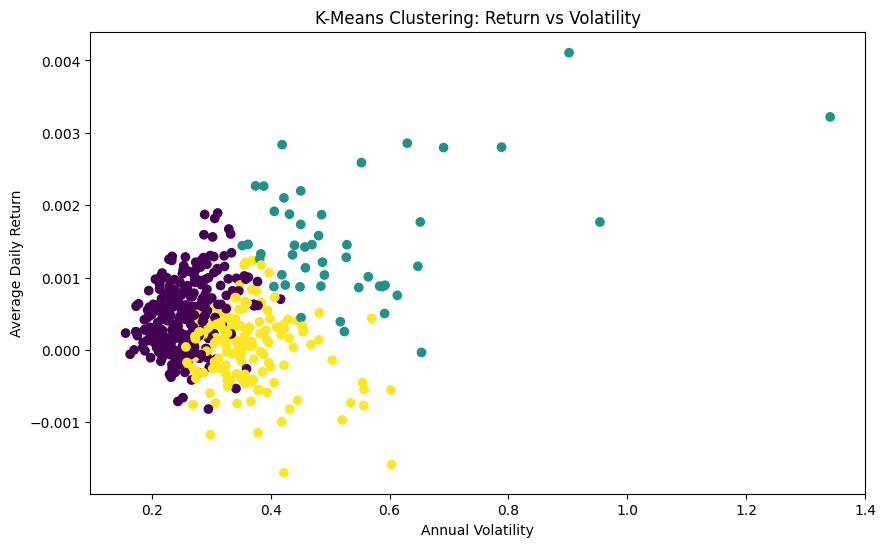

In [124]:
# 21. DIAGRAM: K-MEANS RETURN VS VOLATILITY

plt.figure(figsize=(10,6))
plt.scatter(
    metrics_df["Annual Volatility"],
    metrics_df["Daily Return"],
    c=metrics_df["KMeans Cluster"]
)
plt.xlabel("Annual Volatility")
plt.ylabel("Average Daily Return")
plt.title("K-Means Clustering: Return vs Volatility")
plt.show()

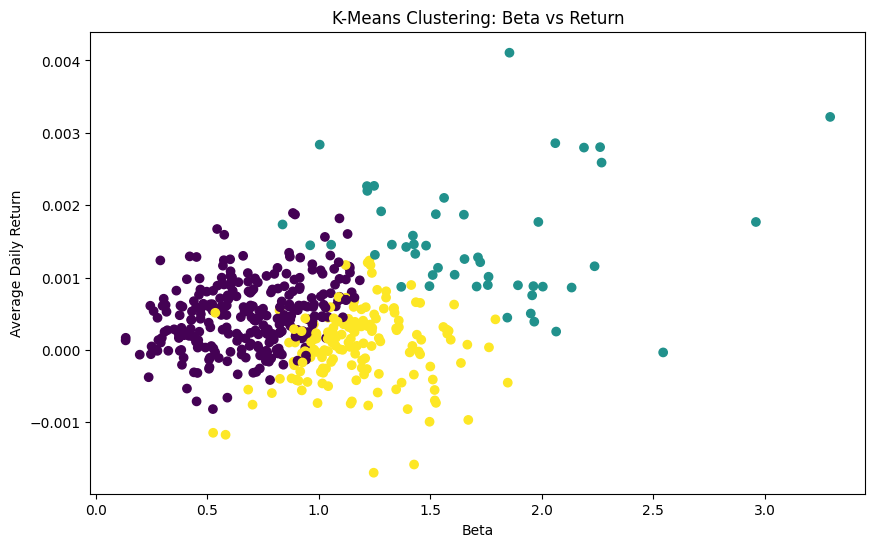

In [125]:
# 22. DIAGRAM: K-MEANS BETA VS RETURN

plt.figure(figsize=(10,6))
plt.scatter(
    metrics_df["Beta"],
    metrics_df["Daily Return"],
    c=metrics_df["KMeans Cluster"]
)
plt.xlabel("Beta")
plt.ylabel("Average Daily Return")
plt.title("K-Means Clustering: Beta vs Return")
plt.show()

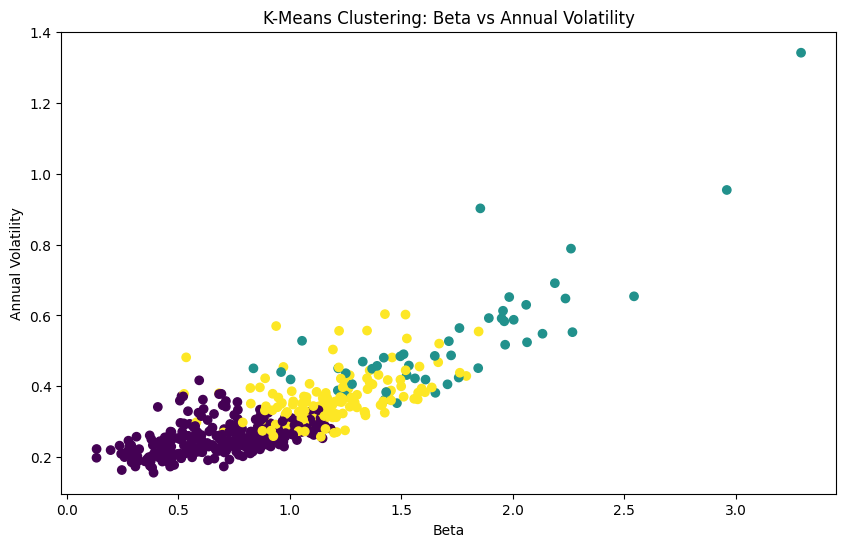

In [126]:
# 23. DIAGRAM: K-MEANS BETA VS VOLATILITY

plt.figure(figsize=(10,6))
plt.scatter(
    metrics_df["Beta"],
    metrics_df["Annual Volatility"],
    c=metrics_df["KMeans Cluster"]
)
plt.xlabel("Beta")
plt.ylabel("Annual Volatility")
plt.title("K-Means Clustering: Beta vs Annual Volatility")
plt.show()

In [127]:
# 24. SHOW EXAMPLE STOCKS IN EACH K-MEANS CLUSTER

for cluster in sorted(metrics_df["KMeans Cluster"].unique()):
    print(f"\nK-Means Cluster {cluster}")
    display(metrics_df[metrics_df["KMeans Cluster"] == cluster].head(10))


K-Means Cluster 0


,Ticker,Daily Return,Beta,Annual Volatility,Agglomerative Cluster,KMeans Cluster
2,ABBV,0.000610,0.299099,0.219958,0,0
4,ABT,-0.000106,0.672317,0.217839,0,0
5,ACGL,0.001165,0.569789,0.253997,0,0
9,ADM,-0.000111,0.551200,0.294043,0,0
10,ADP,0.000423,0.827198,0.221213,0,0
12,AEE,0.000213,0.420490,0.204596,0,0
13,AEP,0.000292,0.425265,0.210029,0,0
15,AFL,0.000948,0.607780,0.214003,0,0
16,AIG,0.000550,0.905681,0.268460,0,0
17,AIZ,0.000616,0.587055,0.257664,0,0



K-Means Cluster 1


,Ticker,Daily Return,Beta,Annual Volatility,Agglomerative Cluster,KMeans Cluster
26,AMD,0.000254,2.064749,0.524187,1,1
32,ANET,0.001876,1.524891,0.431755,1,1
38,APO,0.001460,1.426422,0.362121,1,1
39,APP,0.002802,2.261933,0.788374,2,1
42,ARES,0.001442,1.481072,0.352409,1,1
45,AVGO,0.002101,1.561983,0.422388,1,1
48,AXON,0.002198,1.217541,0.450738,1,1
64,BLDR,0.001135,1.534637,0.458567,1,1
71,BX,0.000876,1.707990,0.405573,1,1
83,CCL,0.000882,1.962671,0.583374,1,1



K-Means Cluster 2


,Ticker,Daily Return,Beta,Annual Volatility,Agglomerative Cluster,KMeans Cluster
0,A,-0.000002,1.024800,0.296259,0,2
1,AAPL,0.000591,1.210689,0.270935,0,2
3,ABNB,0.000074,1.666256,0.467875,1,2
6,ACN,0.000011,1.094208,0.270331,0,2
7,ADBE,-0.000022,1.447974,0.383083,1,2
8,ADI,0.000514,1.339929,0.318058,1,2
11,ADSK,0.000318,1.558665,0.364712,1,2
14,AES,-0.000462,1.015896,0.357445,0,2
20,ALB,-0.000730,1.525588,0.534911,1,2
21,ALGN,-0.000966,1.670528,0.520427,1,2


In [128]:
# 25. SAVE RESULTS AS CSV FILE

metrics_df.to_csv("sp500_stock_segmentation_results.csv", index=False)

print("Results saved as sp500_stock_segmentation_results.csv")

Results saved as sp500_stock_segmentation_results.csv
